# Amazon Reviews — Sentiment Analysis
## CodeAlpha Internship | Task 4

This notebook analyzes Amazon Fine Food Reviews to classify 
customer opinions as Positive, Negative, or Neutral
using Python and TextBlob.


## Step 1
# Import libraries & Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"D:\python\EDA Code Alpha\Reviews.csv", encoding='latin1')
print(f"Shape of the dataset: {df.shape}")
df.info()

Shape of the dataset: (568454, 10)
<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


## Step 2 — Data Cleaning & Preparation


In [17]:
df = df.head(10000)
df = df[['Score', 'Summary', 'Text']].dropna()
print(f"Working with {df.shape[0]} reviews")

Working with 10000 reviews


In [15]:
df

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...
9995,1,constipation,we switched from the advance similac to the or...
9996,5,Constipation Not A Problem if...,"Like the bad reviews say, the organic formula ..."
9997,5,Love this formula!,I wanted to solely breastfeed but was unable t...
9998,5,very convenient,i love the fact that i can get this delieved t...


## Step 3 — Sentiment Analysis

In [16]:

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Text'].apply(get_sentiment)
print(df['Sentiment'].value_counts())

Sentiment
Positive    8814
Negative     983
Neutral      203
Name: count, dtype: int64


## Step 4 — Visualization


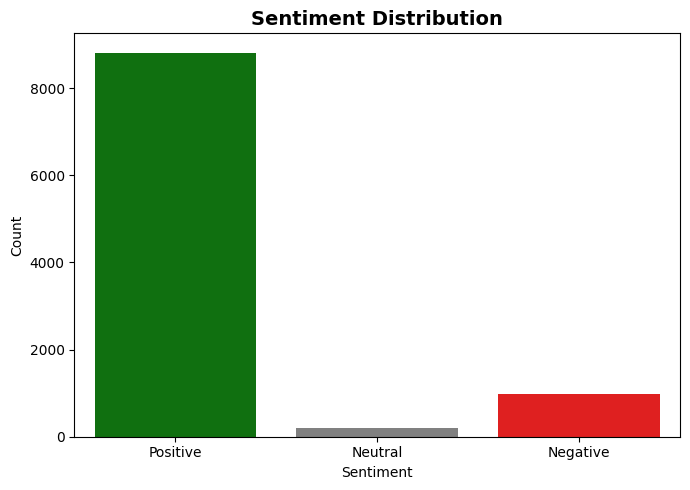

In [8]:

plt.figure(figsize=(7, 5))
sns.countplot(x=df['Sentiment'], 
              order=['Positive', 'Neutral', 'Negative'],
              palette=['green', 'gray', 'red'])
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Insight:
**88% of reviews are Positive, 10% Negative,** 
**and only 2% Neutral. Customers are generally satisfied** 
**with Amazon Fine Food products.**


## Step 5 — Sentiment vs Score
Does the star rating match the sentiment?

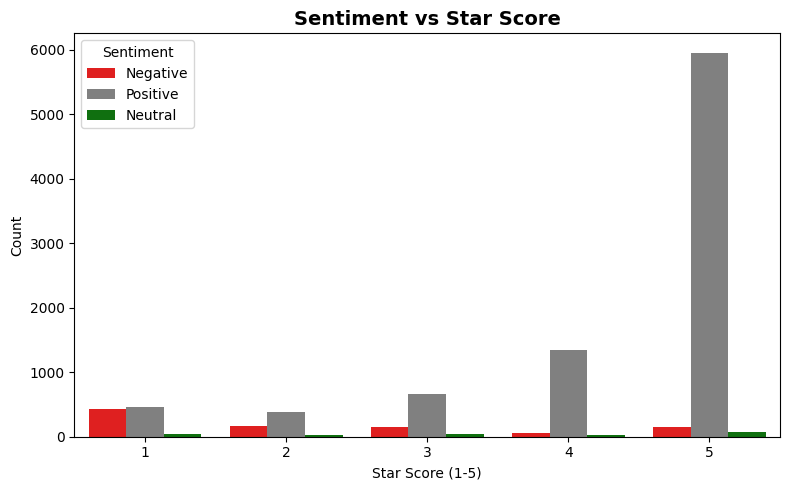

In [9]:

plt.figure(figsize=(8, 5))
sns.countplot(x=df['Score'], hue=df['Sentiment'],
              palette=['red', 'gray', 'green'])
plt.title('Sentiment vs Star Score', fontsize=14, fontweight='bold')
plt.xlabel('Star Score (1-5)')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Insight: 
**Sentiment aligns well with star ratings.** 
**5-star reviews are mostly Positive, while**
**1 and 2-star reviews show clear Negative sentiment.**




## Key Insights — Sentiment Analysis

1. 88% of reviews are Positive — customers are generally satisfied
2. Only 10% of reviews are Negative
3. Sentiment aligns well with star ratings
4. 5-star reviews are dominated by Positive sentiment
5. 1 and 2-star reviews show clear Negative sentiment